In [1]:

import os, re, socket, sys, yaml
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "scripts" else Path.cwd().resolve()
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

with CONFIG_PATH.open("r") as f:
    config = yaml.safe_load(f)

ENV = os.getenv("MY_ENV")
if ENV is None:
    host = socket.gethostname()
    if host in config:
        ENV = host
    elif "tiziano_mac_mini" in config:
        ENV = "tiziano_mac_mini"
    else:
        ENV = next(iter(config))

paths = config[ENV]["paths"]
for path_key in ("src_path", "useful_stuff_path"):
    path = paths.get(path_key)
    if path and path not in sys.path:
        sys.path.append(path)

from useful_stuff.general_utils import BrainAreas, TimeSeries, decode_matlab_strings, print_wise, truncate_colormap
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.II import dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from image_processing.feature_extraction import save_srp_pca_projected_features


def resolve_tiziano_path(paths, relative_path, project_subdir="metrics_II"):
    tiziano_root = Path(paths["livingstone_lab"]) / "tiziano"
    candidates = [
        tiziano_root / relative_path,
        tiziano_root / project_subdir / relative_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find any of: " + ", ".join(str(c) for c in candidates))


def load_img_natraster(paths, monkey_name, date, new_fs=None, brain_area=None):
    rasters_path = resolve_tiziano_path(paths, Path("data") / f"{monkey_name}_natraster{date}.mat")
    with h5py.File(rasters_path, "r") as f:
        rasters = f["natraster"][:]
    rasters = rasters.astype(np.float32).transpose(2, 1, 0)
    rasters = TimeSeries(rasters, 1000)
    if brain_area is not None:
        rasters = BrainAreas(monkey_name).slice_brain_area(rasters, brain_area)
    if new_fs is not None:
        rasters.resample(new_fs)
    return rasters


def rename_talia_dataset(monkey_presentation_order):
    renamed = []
    for f in monkey_presentation_order:
        renamed.append(re.sub(r"([a-zA-Z])([0-9])", r"\1_\2", f).replace(" ", ""))
    return renamed


def map_image_order_from_ann_to_monkey(paths, monkey_name, date, dataset):
    allimgs_path = resolve_tiziano_path(paths, Path("data") / f"{monkey_name}_allimages{date}.mat")
    with h5py.File(allimgs_path, "r") as f:
        try:
            refs = f["allimages"][:]
        except KeyError:
            refs = f["uniqueImage"][:]
        monkey_presentation_order = sorted(set(decode_matlab_strings(f, refs)))
    ann_presentation_order = [Path(path).name for path, _ in dataset.samples]
    if Path(dataset.root).name == "talia_20each_tizi":
        monkey_presentation_order = rename_talia_dataset(monkey_presentation_order)
    mapping_idx = [ann_presentation_order.index(x) for x in monkey_presentation_order]
    newly_ordered_ann = [ann_presentation_order[i] for i in mapping_idx]
    assert newly_ordered_ann == monkey_presentation_order
    return np.asarray(mapping_idx, dtype=int)


def feature_label(cfg):
    return f"{cfg.dataset_name}_{cfg.n_srp_components}_to_{cfg.n_pca_components}_srp_to_pca_{cfg.PCs_dataset}_{cfg.pooling}pool"


def result_path(paths, prefix, cfg, layer_name):
    results_dir = Path(paths["livingstone_lab"]) / "tiziano" / cfg.project_subdir / "results"
    results_dir.mkdir(parents=True, exist_ok=True)
    fs = cfg.new_fs
    name = (
        f"{prefix}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_"
        f"{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{layer_name}_"
        f"{feature_label(cfg)}_{fs}Hz.npz"
    )
    return results_dir / name


def load_srp_pca_features(paths, cfg, layer_name, idx_ord):
    feature_path = save_srp_pca_projected_features(
        paths,
        cfg.model_name,
        layer_name,
        cfg.dataset_name,
        cfg.PCs_dataset,
        cfg.n_srp_components,
        cfg.n_pca_components,
        cfg.pooling,
    )
    data = np.load(feature_path)
    features = data["features" if "features" in data.files else data.files[0]]
    if features.shape[0] < len(idx_ord):
        raise ValueError(f"{feature_path} has {features.shape[0]} rows but {len(idx_ord)} ordered stimuli are needed")
    return features[idx_ord].T, feature_path


def init_static_dRSA_dynII(ba_raster, signal_RDM_metric, model_RDM_metric, k):
    drsa_obj = dRSA(signal_RDM_metric, model_RDM_metric)
    drsa_obj.compute_RDM_timeseries(ba_raster, "signal")
    dyn_ii_obj = dynInformationImbalance(signal_RDM_metric, model_RDM_metric, k)
    dyn_ii_obj.compute_RDM_timeseries(ba_raster, "signal")
    dyn_ii_obj.compute_distance_ranks_timeseries("signal")
    return drsa_obj, dyn_ii_obj


def compute_static_dRSA_dynII(paths, rank, layer_name, drsa_obj, dyn_ii_obj, idx_ord, cfg):
    save_name_A2B = result_path(paths, f"static_dynII_A2B_k{cfg.k}", cfg, layer_name)
    save_name_B2A = result_path(paths, f"static_dynII_B2A_k{cfg.k}", cfg, layer_name)
    save_name_drsa = result_path(paths, "static_dRSA", cfg, layer_name)
    if save_name_drsa.exists() and save_name_A2B.exists() and save_name_B2A.exists():
        print_wise(f"model already exists at {save_name_A2B}", rank=rank)
        return
    if not hasattr(drsa_obj, "signal_RDM_timeseries"):
        raise AttributeError("drsa_obj must have 'signal_RDM_timeseries'")
    if not hasattr(dyn_ii_obj, "signal_distance_ranks_timeseries"):
        raise AttributeError("dyn_ii_obj must have 'signal_distance_ranks_timeseries'")
    features, feature_path = load_srp_pca_features(paths, cfg, layer_name, idx_ord)
    drsa_obj.compute_RDM(features, "model")
    drsa = drsa_obj.compute_static_dRSA()
    dyn_ii_obj.set_RDM(drsa_obj.get_RDM("model"), "model")
    dyn_ii_obj.compute_distance_ranks("model")
    dyn_ii = dyn_ii_obj.compute_both_static_dynII()
    np.savez_compressed(save_name_drsa, drsa.get_array(), feature_path=str(feature_path))
    np.savez_compressed(save_name_A2B, dyn_ii[0].get_array(), feature_path=str(feature_path))
    np.savez_compressed(save_name_B2A, dyn_ii[1].get_array(), feature_path=str(feature_path))
    print_wise(f"model saved at {save_name_A2B} and {save_name_drsa}", rank=rank)


def init_static_dynII(ba_raster, signal_RDM_metric, model_RDM_metric, k):
    dyn_ii_obj = dynInformationImbalance(signal_RDM_metric, model_RDM_metric, k)
    dyn_ii_obj.compute_RDM_timeseries(ba_raster, "signal")
    dyn_ii_obj.compute_distance_ranks_timeseries("signal")
    return dyn_ii_obj


def compute_static_dynII(paths, rank, layer_name, dyn_ii_obj, idx_ord, cfg):
    save_name_A2B = result_path(paths, f"static_dynII_A2B_k{cfg.k}", cfg, layer_name)
    save_name_B2A = result_path(paths, f"static_dynII_B2A_k{cfg.k}", cfg, layer_name)
    if save_name_A2B.exists() and save_name_B2A.exists():
        print_wise(f"model already exists at {save_name_A2B}", rank=rank)
        return
    if not hasattr(dyn_ii_obj, "signal_distance_ranks_timeseries"):
        raise AttributeError("dyn_ii_obj must have 'signal_distance_ranks_timeseries'")
    features, feature_path = load_srp_pca_features(paths, cfg, layer_name, idx_ord)
    dyn_ii_obj.compute_RDM(features, "model")
    dyn_ii_obj.compute_distance_ranks("model")
    dyn_ii = dyn_ii_obj.compute_both_static_dynII()
    np.savez_compressed(save_name_A2B, dyn_ii[0].get_array(), feature_path=str(feature_path))
    np.savez_compressed(save_name_B2A, dyn_ii[1].get_array(), feature_path=str(feature_path))
    print_wise(f"model saved at {save_name_A2B}", rank=rank)


def init_static_dRSA(ba_raster, signal_RDM_metric, model_RDM_metric):
    drsa_obj = dRSA(signal_RDM_metric, model_RDM_metric)
    drsa_obj.compute_RDM_timeseries(ba_raster, "signal")
    return drsa_obj


def compute_static_dRSA(paths, rank, layer_name, drsa_obj, idx_ord, cfg):
    save_name = result_path(paths, "static_dRSA", cfg, layer_name)
    if save_name.exists():
        print_wise(f"model already exists at {save_name}", rank=rank)
        return
    if not hasattr(drsa_obj, "signal_RDM_timeseries"):
        raise AttributeError("drsa_obj must have 'signal_RDM_timeseries'")
    features, feature_path = load_srp_pca_features(paths, cfg, layer_name, idx_ord)
    drsa_obj.compute_RDM(features, "model")
    drsa = drsa_obj.compute_static_dRSA()
    np.savez_compressed(save_name, drsa.get_array(), feature_path=str(feature_path))
    print_wise(f"model saved at {save_name}", rank=rank)

print(f"Using config: {ENV}")
print(f"Feature root: {Path(paths['data_path']) / 'models'}")
print(f"Results root: {Path(paths['livingstone_lab']) / 'tiziano' / 'metrics_II' / 'results'}")


Using config: tiziano_mac_mini
Feature root: /Users/tizianocausin/sd_local/models
Results root: /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results


In [122]:

from dataclasses import dataclass

@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    folder_name: str = "talia_20each_tizi"
    dataset_name: str = "talia_20each_tizi"
    project_subdir: str = "metrics_II"
    PCs_dataset: str = "imagenet_val"
    brain_area: str = "V1"
    brain_area_slice: tuple[int, int] = (0, 20)
    new_fs: int = 100
    signal_RDM_metric: str = "correlation"
    model_RDM_metric: str = "correlation"
    k: int = 50
    model_name: str = "alexnet"
    pkg: str = "torchvision"
    img_size: int = 224
    pooling: str = "all"
    n_srp_components: int = 10000
    n_pca_components: int = 1000

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
print(layers)


['features.0', 'features.4', 'features.7', 'features.9', 'features.11', 'classifier.2', 'classifier.5']


In [123]:
ba_raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs, brain_area=cfg.brain_area)
print("using:", cfg.brain_area, ba_raster.shape(), ba_raster.get_fs())

using: V1 (26, 30, 776) 100


In [124]:

dataset = ImageFolder(
    root=Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name,
    is_valid_file=lambda x: not x.endswith("Thumbs.db"),
    allow_empty=True,
)
print(f"Loaded {len(dataset)} images from {dataset.root}")


Loaded 776 images from /Users/tizianocausin/livingstone_lab_local/Stimuli/talia_20each_tizi


In [125]:
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)

# II and dRSA

In [126]:

base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
print(f"Computing {len(layers)} layers with {feature_label(cfg)}")


Computing 7 layers with talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool


18:50:24 - rank 0 model saved at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dynII_A2B_k50_correlation-correlation_three0_250313_V1_alexnet_features.0_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz and /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dRSA_correlation-correlation_three0_250313_V1_alexnet_features.0_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:50:24 - rank 0 model saved at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dynII_A2B_k50_correlation-correlation_three0_250313_V1_alexnet_features.4_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz and /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dRSA_correlation-correlation_three0_250313_V1_alexnet_features.4_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:50:24 - rank 0 model saved at /Users/tizi

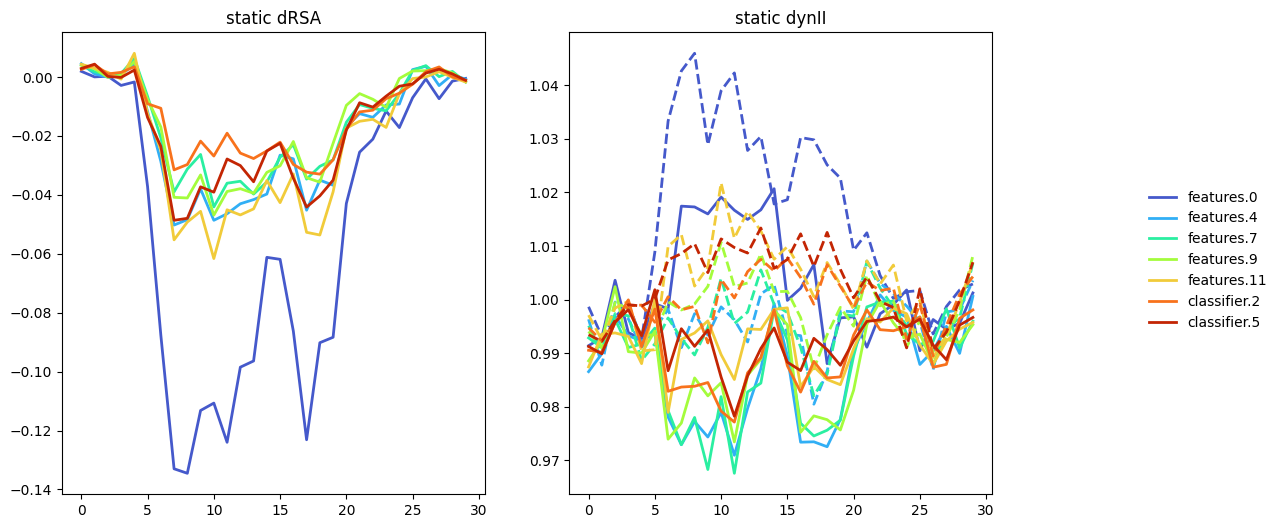

In [127]:

drsa_obj, dyn_ii_obj = init_static_dRSA_dynII(
    ba_raster,
    cfg.signal_RDM_metric,
    cfg.model_RDM_metric,
    cfg.k,
)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for i_col, layer in enumerate(layers):
    color = cmap(i_col / max(len(layers) - 1, 1))
    compute_static_dRSA_dynII(paths, 0, layer, drsa_obj, dyn_ii_obj, idx_ord, cfg)
    drsa = np.load(result_path(paths, "static_dRSA", cfg, layer))["arr_0"]
    A2B = np.load(result_path(paths, f"static_dynII_A2B_k{cfg.k}", cfg, layer))["arr_0"]
    B2A = np.load(result_path(paths, f"static_dynII_B2A_k{cfg.k}", cfg, layer))["arr_0"]
    ax[0].plot(drsa, color=color, linewidth=2, label=layer)
    ax[1].plot(A2B, color=color, linewidth=2, linestyle="--")
    ax[1].plot(B2A, color=color, linewidth=2)

ax[0].set_title("static dRSA")
ax[1].set_title("static dynII")
fig.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()


# Information Imbalance

In [10]:

# Static dynII-only run, useful when dRSA outputs already exist or are not needed.


18:36:40 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_alexnet_features.0_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:36:40 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_alexnet_features.4_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:36:40 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_alexnet_features.7_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:36:40 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_alexnet_features.9_talia_20each_tizi_10000_to_1000_sr

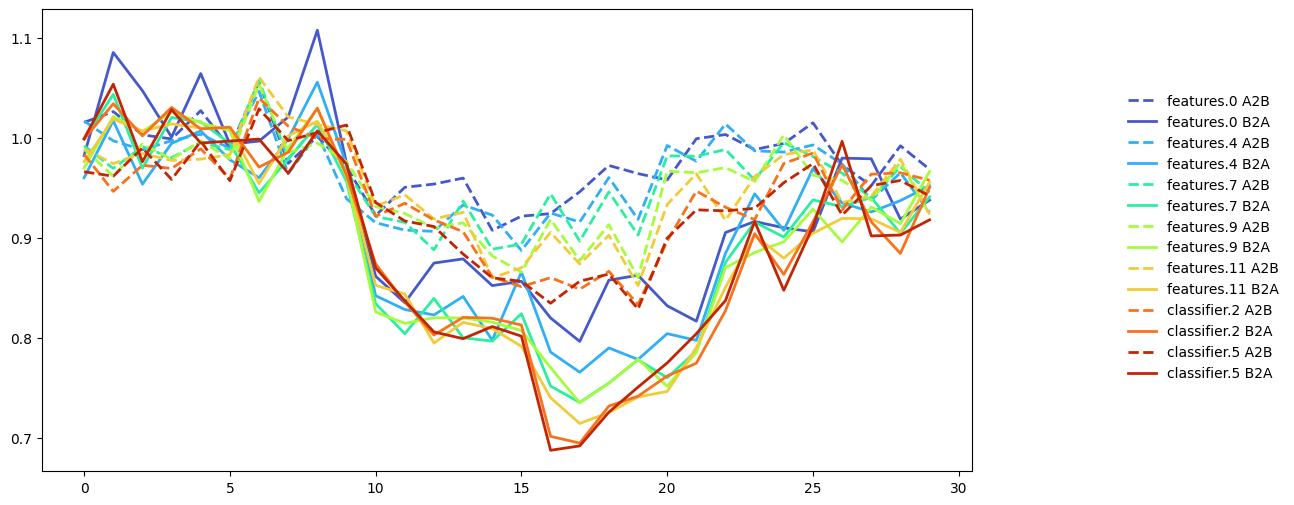

In [11]:

fig, ax = plt.subplots(1, figsize=(12, 6))
dyn_ii_obj = init_static_dynII(ba_raster, cfg.signal_RDM_metric, cfg.model_RDM_metric, cfg.k)
for i_col, layer in enumerate(layers):
    color = cmap(i_col / max(len(layers) - 1, 1))
    compute_static_dynII(paths, 0, layer, dyn_ii_obj, idx_ord, cfg)
    A2B = np.load(result_path(paths, f"static_dynII_A2B_k{cfg.k}", cfg, layer))["arr_0"]
    B2A = np.load(result_path(paths, f"static_dynII_B2A_k{cfg.k}", cfg, layer))["arr_0"]
    ax.plot(A2B, color=color, linewidth=2, linestyle="--", label=f"{layer} A2B")
    ax.plot(B2A, color=color, linewidth=2, label=f"{layer} B2A")
fig.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()


# dRSA

In [12]:

# Static dRSA-only run, useful when static dynII outputs already exist or are not needed.


18:41:19 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dRSA_euclidean-cosine_three0_250313_AIT_alexnet_features.0_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:41:19 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dRSA_euclidean-cosine_three0_250313_AIT_alexnet_features.4_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:41:19 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dRSA_euclidean-cosine_three0_250313_AIT_alexnet_features.7_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_100Hz.npz
18:41:19 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/results/static_dRSA_euclidean-cosine_three0_250313_AIT_alexnet_features.9_talia_20each_tizi_10000_to_1000_srp_to_pca_imagenet_val_allpool_10

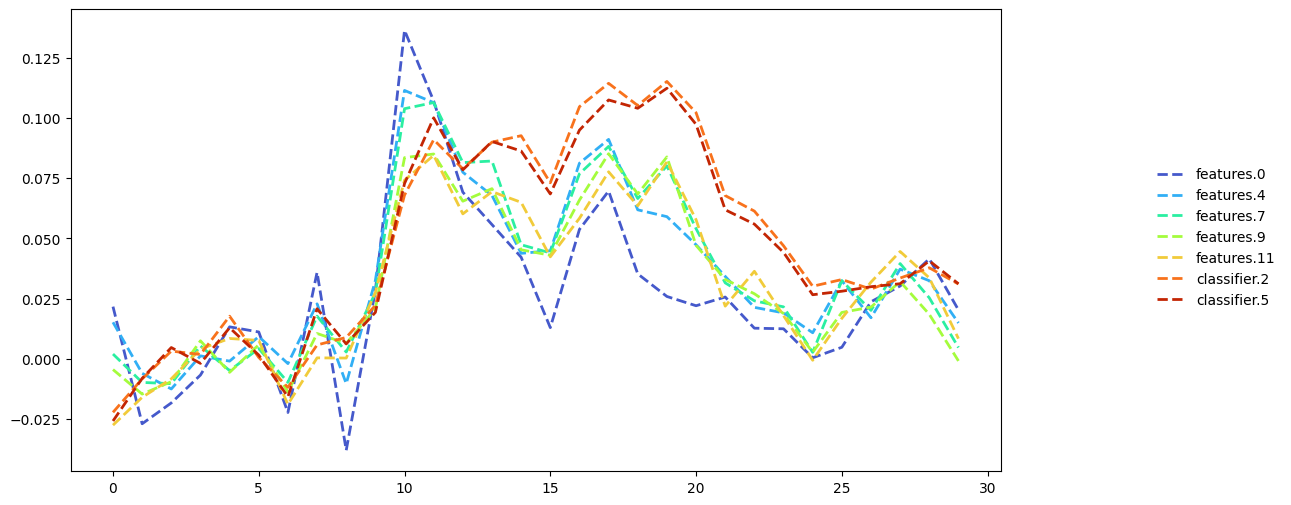

In [70]:

fig, ax = plt.subplots(1, figsize=(12, 6))
drsa_obj = init_static_dRSA(ba_raster, cfg.signal_RDM_metric, cfg.model_RDM_metric)
for i_col, layer in enumerate(layers):
    color = cmap(i_col / max(len(layers) - 1, 1))
    compute_static_dRSA(paths, 0, layer, drsa_obj, idx_ord, cfg)
    drsa = np.load(result_path(paths, "static_dRSA", cfg, layer))["arr_0"]
    ax.plot(drsa, color=color, linewidth=2, linestyle="--", label=layer)
fig.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()
